In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt

In [27]:
from torch.utils.data import Dataset, DataLoader
from skimage import io, transform
import os
import random

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])

class FaceLandmarksDataset(Dataset):
    """Face Landmarks dataset."""

    def __init__(self, csv_file, img_root_dir, transform=None, augment=False):
        self.landmarks_frame = []
        file = open(csv_file, "r")
        while True:
            content=file.readline()
            if not content:
                break
            self.landmarks_frame.append(content.split())
        file.close()
        self.landmarks_frame = self.landmarks_frame[2:]

        self.img_root_dir = img_root_dir
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.landmarks_frame)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        img_name = os.path.join(self.img_root_dir, self.landmarks_frame[idx][0])
        image = io.imread(img_name)
        landmarks = self.landmarks_frame[idx][1:]
        landmarks = np.array([landmarks], dtype=float).reshape(-1, 2)
        # landmarks order: left_eye, right_eye, nose, left_mouth, right_mouth

        # Horizontal flip augmentation
        if self.augment and random.random() > 0.5:
            image = np.fliplr(image).copy()
            img_w = image.shape[1]  # 178
            landmarks[:, 0] = img_w - landmarks[:, 0]
            # Swap: left_eye(0) <-> right_eye(1), left_mouth(3) <-> right_mouth(4)
            landmarks[[0, 1]] = landmarks[[1, 0]]
            landmarks[[3, 4]] = landmarks[[4, 3]]

        scaled_landmarks = landmarks.copy()
        scaled_landmarks[:, 0], scaled_landmarks[:, 1] = scaled_landmarks[:, 0] / 178, scaled_landmarks[:, 1] / 218
        if self.transform:
            image_tr = self.transform(image)
        scaled_landmarks = scaled_landmarks.reshape(-1)
        sample = {'image': image, 'image_tr':image_tr, 'landmarks': landmarks, 'scaled_landmarks': scaled_landmarks}

        return sample


In [28]:
# from torchvision import datasets
# from torchvision import transforms
# full_dataset = datasets.CelebA(root='./',split="train", target_type="landmarks" ,download=True, transform=torchvision.transforms.Compose([transforms.PILToTensor()]))

In [29]:
from torchvision import datasets
from torchvision import transforms
full_dataset_root = '/home/tr1bo/Documents/1. School/1. 3B/DeepLearning/lab2,3,4/data/img_align_celeba'
dataset_landmarks = '/home/tr1bo/Documents/1. School/1. 3B/DeepLearning/lab2,3,4/data/landmark/list_landmarks_align_celeba.txt'
full_dataset = FaceLandmarksDataset(dataset_landmarks, full_dataset_root, transform=transform)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_set, test_set = torch.utils.data.random_split(full_dataset, [train_size, test_size])

print(train_set.__len__(), test_set.__len__())

162079 40520


In [30]:
sample = train_set[1000]
landmarks = sample['landmarks']
image = sample['image']
print(sample['image_tr'][0,:5,0:5])
print(sample['scaled_landmarks'].shape)
def show_landmarks(image, landmarks):
    """Show image with landmarks"""
    plt.imshow(image)
    plt.scatter(landmarks[:, 0], landmarks[:, 1], s=5, marker='.', c='r')
    plt.pause(0.001)  # pause a bit so that plots are updated

print(train_set[0])


tensor([[0.9608, 0.9608, 0.9569, 0.9529, 0.9529],
        [0.9569, 0.9569, 0.9569, 0.9569, 0.9569],
        [0.9490, 0.9529, 0.9569, 0.9608, 0.9608],
        [0.9412, 0.9490, 0.9569, 0.9647, 0.9647],
        [0.9373, 0.9451, 0.9529, 0.9608, 0.9647]])
(10,)
{'image': array([[[ 21,  32,  96],
        [ 21,  32,  96],
        [ 21,  32,  96],
        ...,
        [ 19,  38, 106],
        [ 19,  38, 104],
        [ 19,  38, 104]],

       [[ 21,  32,  96],
        [ 21,  32,  96],
        [ 21,  32,  96],
        ...,
        [ 19,  38, 106],
        [ 19,  38, 104],
        [ 19,  38, 104]],

       [[ 21,  32,  96],
        [ 21,  32,  96],
        [ 21,  32,  96],
        ...,
        [ 19,  38, 106],
        [ 19,  38, 104],
        [ 19,  38, 104]],

       ...,

       [[135, 123, 161],
        [127, 115, 153],
        [121, 109, 147],
        ...,
        [120, 109, 149],
        [131, 123, 162],
        [128, 120, 159]],

       [[129, 117, 155],
        [136, 124, 162],
        [1

In [31]:
dataloader = DataLoader(train_set, batch_size=4,
                        shuffle=True, num_workers=0)

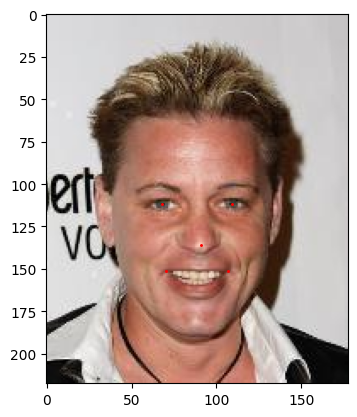

In [32]:
for i in dataloader:
    image = i['image']
    landmarks = i['landmarks']

    img = image[0]          # (218, 178, 3)
    lm = landmarks[0]       # (5, 2)

    plt.figure()
    show_landmarks(img, lm)
    plt.show()

    break

# Model

In [33]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_chanels, **kwargs):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_chanels, **kwargs)
        self.bn = nn.BatchNorm2d(out_chanels)

    def forward(self, x):
        return F.relu(self.bn(self.conv(x)))

class InceptionBlock(nn.Module):
    def __init__(self,  in_channels,  out_1x1, red_3x3, out_3x3, red_5x5, out_5x5, out_pool):

        super(InceptionBlock, self).__init__()
        self.branch1 = ConvBlock(in_channels, out_1x1, kernel_size=1)
        self.branch2 = nn.Sequential(
            ConvBlock(in_channels, red_3x3, kernel_size=1, padding=0),
            ConvBlock(red_3x3, out_3x3, kernel_size=3, padding=1))
        self.branch3 = nn.Sequential(
            ConvBlock(in_channels, red_5x5, kernel_size=1),
            ConvBlock(red_5x5, out_5x5, kernel_size=5, padding=2))
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, padding=1, stride=1),
            ConvBlock(in_channels, out_pool, kernel_size=1))

    def forward(self, x):
        branches = (self.branch1, self.branch2, self.branch3, self.branch4)
        return torch.cat([branch(x) for branch in branches], 1)

In [37]:
class InceptionModel(nn.Module):
    def __init__(self, aux = False, residual = True, num_classes = 1000):
        super(InceptionModel, self).__init__()
        self.aux = aux
        self.residual  = residual
        self.dropout = nn.Dropout(p=0.4)
        self.fc = nn.Linear(512, num_classes)

        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.avgpool = nn.AvgPool2d(kernel_size=(7,6), stride=1)

        self.conv1 = ConvBlock(in_channels=3, out_chanels=64, kernel_size=(7,7), stride=(2,2), padding=(3,3))
        self.conv2 = ConvBlock(in_channels=64, out_chanels=192, kernel_size=3, stride=1, padding=1)

        self.incept3a = InceptionBlock(in_channels=192, out_1x1=64, red_3x3=96, out_3x3=128, red_5x5=16, out_5x5=32, out_pool=32)
        self.incept3b = InceptionBlock(in_channels=256, out_1x1=128, red_3x3=128, out_3x3=192, red_5x5=32, out_5x5=112, out_pool=80)

        self.incept4a = InceptionBlock(in_channels=512, out_1x1=192, red_3x3=96, out_3x3=208, red_5x5=16, out_5x5=48, out_pool=64)
        self.incept4b = InceptionBlock(in_channels=512, out_1x1=160, red_3x3=112, out_3x3=224, red_5x5=24, out_5x5=64, out_pool=64)

        self.incept5a = InceptionBlock(in_channels=512, out_1x1=256, red_3x3=160, out_3x3=320, red_5x5=32, out_5x5=128, out_pool=128)
        self.incept5b = InceptionBlock(in_channels=832, out_1x1=128, red_3x3=112, out_3x3=256, red_5x5=32, out_5x5=64, out_pool=64)

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.maxpool(x)
        x = self.incept3a(x)
        x = self.incept3b(x)
        residual = self.maxpool(x)

        x = self.incept4a(residual)
        x = self.incept4b(x)
        x += residual
        residual = self.maxpool(x)

        x = self.incept5a(residual)
        x = self.incept5b(x)
        x += residual
        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.dropout(x)
        x = F.relu(self.fc(x))

        return x

In [35]:
dummy_input = torch.rand(8,3,218,178)
print(dummy_input.shape)

torch.Size([8, 3, 218, 178])


In [38]:
net = InceptionModel(num_classes=10)
out = net(dummy_input)

print(out.shape)

torch.Size([8, 10])


In [39]:
net

InceptionModel(
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=10, bias=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (avgpool): AvgPool2d(kernel_size=(7, 6), stride=1, padding=0)
  (conv1): ConvBlock(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv2): ConvBlock(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (incept3a): InceptionBlock(
    (branch1): ConvBlock(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (branch2): Sequential(
      (0): ConvBlock(
        (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1))
     

In [41]:
from torchvision import models
class Network(nn.Module):
    def __init__(self,num_classes=10):
        super().__init__()
        self.model=models.resnet18()
        self.model.conv1=nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.fc=nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        x=F.relu(self.model(x))
        return x

# Training

In [42]:
from torch.optim.lr_scheduler import StepLR
def inference(model, device):
    model.eval()
    with torch.no_grad():
        data = test_set[-1]
        image, target = torch.tensor(data["image_tr"], dtype=torch.float32).unsqueeze(0).to(device),  torch.tensor(data["scaled_landmarks"],dtype=torch.float32).unsqueeze(0).to(device)
        print(image.shape)
        output = model(image)
        landmarks = np.array([output.cpu().detach()], dtype=float).reshape(-1, 2)
        landmarks[:, 0], landmarks[:, 1] = landmarks[:, 0] * 178, landmarks[:, 1] * 218
        landmarks = np.int8(landmarks)
        loss = F.mse_loss(output, target, reduction='sum').item()
        print('loss: ', loss, 'out: ', landmarks)

def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, data in enumerate(train_loader):
        image, target = data['image_tr'].to(device).float(), data['scaled_landmarks'].to(device).float()
        optimizer.zero_grad()
        output = model(image)
        loss = F.mse_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(image), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))


def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for data in test_loader:
            image, target = data['image_tr'].to(device).float(), data['scaled_landmarks'].to(device).float()
            output = model(image)
            test_loss += F.mse_loss(output, target, reduction='sum').item()  # sum up batch loss
    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}\n'.format(test_loss))


def main():
    epochs = 1
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Using device:', device)
    train_loader = DataLoader(train_set, batch_size=64,
                        shuffle=True, num_workers=0)
    test_loader = DataLoader(test_set, batch_size=64,
                        shuffle=True, num_workers=0)
    # model = InceptionModel(num_classes=10)
    model = Network(10)
    model.to(device)
    optimizer = torch.optim.Adadelta(model.parameters(), lr=0.001)
    scheduler = StepLR(optimizer, step_size=1, gamma=0.7)
    for epoch in range(1, epochs + 1):
        train(model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()
    torch.save(model.state_dict(), "./own_res_incept5.pt")
    inference(model, device)

In [ ]:
main()

Using device: cuda
Train Epoch: 1 [0/162079 (0%)]	Loss: 0.229026
Train Epoch: 1 [6400/162079 (4%)]	Loss: 0.185886
Train Epoch: 1 [12800/162079 (8%)]	Loss: 0.163906
Train Epoch: 1 [19200/162079 (12%)]	Loss: 0.153959
Train Epoch: 1 [25600/162079 (16%)]	Loss: 0.146158
Train Epoch: 1 [32000/162079 (20%)]	Loss: 0.144296
Train Epoch: 1 [38400/162079 (24%)]	Loss: 0.143585
Train Epoch: 1 [44800/162079 (28%)]	Loss: 0.143467
Train Epoch: 1 [51200/162079 (32%)]	Loss: 0.142929
Train Epoch: 1 [57600/162079 (36%)]	Loss: 0.143485
Train Epoch: 1 [64000/162079 (39%)]	Loss: 0.143293
Train Epoch: 1 [70400/162079 (43%)]	Loss: 0.119662
Train Epoch: 1 [76800/162079 (47%)]	Loss: 0.118824
Train Epoch: 1 [83200/162079 (51%)]	Loss: 0.119912
Train Epoch: 1 [89600/162079 (55%)]	Loss: 0.118906
Train Epoch: 1 [96000/162079 (59%)]	Loss: 0.119225
Train Epoch: 1 [102400/162079 (63%)]	Loss: 0.118848
Train Epoch: 1 [108800/162079 (67%)]	Loss: 0.119833
Train Epoch: 1 [115200/162079 (71%)]	Loss: 0.118477
Train Epoch: 1 [1

/tmp/ipykernel_106909/1974557045.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image, target = torch.tensor(data["image_tr"], dtype=torch.float32).unsqueeze(0).to(device),  torch.tensor(data["scaled_landmarks"],dtype=torch.float32).unsqueeze(0).to(device)


In [ ]:
# Сургахаас өмнө нэг batch шалгах
train_loader_check = DataLoader(train_set, batch_size=4, shuffle=True)
batch = next(iter(train_loader_check))

print("Image shape:", batch['image_tr'].shape)          # (4, 3, 128, 128) байх ёстой
print("Landmark shape:", batch['landmarks'].shape)        # (4, 5, 2) байх ёстой
print("Scaled Landmark shape:", batch['scaled_landmarks'].shape)  # (4, 10) байх ёстой
print("Landmark min/max:", batch['landmarks'].min().item(), batch['landmarks'].max().item())  
# [0, 218] байх ёстой — raw pixel coordinates
print("Scaled Landmark min/max:", batch['scaled_landmarks'].min().item(), batch['scaled_landmarks'].max().item())
# [0, 1] хооронд байх ёстой — normalized coordinates
print("Scaled landmark sample:\n", batch['scaled_landmarks'][0])

Image shape: torch.Size([4, 3, 218, 178])
Landmark shape: torch.Size([4, 5, 2])
Scaled Landmark shape: torch.Size([4, 10])
Landmark min/max: 68.0 154.0
Scaled Landmark min/max: 0.38202247191011235 0.7064220183486238
Scaled landmark sample:
 tensor([0.3876, 0.5138, 0.6067, 0.5092, 0.4944, 0.6101, 0.4213, 0.6972, 0.5674,
        0.6972], dtype=torch.float64)


In [ ]:
import time
network = Network(10)
network.cuda()

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(network.parameters(), lr=0.0001)
train_loader = DataLoader(train_set, batch_size=64,
                    shuffle=True, num_workers=0)
valid_loader = DataLoader(test_set, batch_size=64,
                    shuffle=True, num_workers=0)
loss_min = np.inf
num_epochs = 10

start_time = time.time()
for epoch in range(1,num_epochs+1):

    loss_train = 0
    loss_valid = 0
    running_loss = 0

    network.train()
    for step in range(1,len(train_loader)+1):

        data = next(iter(train_loader))
        images, landmarks = data["image_tr"].float(), data["landmarks"].float()
        images = images.cuda()
        landmarks = landmarks.view(landmarks.size(0),-1).cuda()

        predictions = network(images)

        # clear all the gradients before calculating them
        optimizer.zero_grad()

        # find the loss for the current step
        loss_train_step = criterion(predictions, landmarks)

        # calculate the gradients
        loss_train_step.backward()

        # update the parameters
        optimizer.step()

        loss_train += loss_train_step.item()
        running_loss = loss_train/step

        # print_overwrite(step, len(train_loader), running_loss, 'train')

    network.eval()
    with torch.no_grad():

        for step in range(1,len(valid_loader)+1):

            data = next(iter(train_loader))
            images, landmarks = data["image_tr"].float(), data["landmarks"].float()
            images = images.cuda()
            landmarks = landmarks.view(landmarks.size(0),-1).cuda()

            predictions = network(images)

            # find the loss for the current step
            loss_valid_step = criterion(predictions, landmarks)

            loss_valid += loss_valid_step.item()
            running_loss = loss_valid/step

            # print_overwrite(step, len(valid_loader), running_loss, 'valid')

    loss_train /= len(train_loader)
    loss_valid /= len(valid_loader)

    print('\n--------------------------------------------------')
    print('Epoch: {}  Train Loss: {:.4f}  Valid Loss: {:.4f}'.format(epoch, loss_train, loss_valid))
    print('--------------------------------------------------')

    if loss_valid < loss_min:
        loss_min = loss_valid
        torch.save(network.state_dict(), 'face_landmarks.pth')
        print("\nMinimum Validation Loss of {:.4f} at epoch {}/{}".format(loss_min, epoch, num_epochs))
        print('Model Saved\n')

print('Training Complete')
print("Total Elapsed Time : {} s".format(time.time()-start_time))


--------------------------------------------------
Epoch: 1  Train Loss: 4179.5872  Valid Loss: 2322.3860
--------------------------------------------------

Minimum Validation Loss of 2322.3860 at epoch 1/10
Model Saved


--------------------------------------------------
Epoch: 2  Train Loss: 2317.6483  Valid Loss: 2316.4142
--------------------------------------------------

Minimum Validation Loss of 2316.4142 at epoch 2/10
Model Saved


--------------------------------------------------
Epoch: 3  Train Loss: 2315.2929  Valid Loss: 2315.2327
--------------------------------------------------

Minimum Validation Loss of 2315.2327 at epoch 3/10
Model Saved


--------------------------------------------------
Epoch: 4  Train Loss: 2314.8999  Valid Loss: 2314.8830
--------------------------------------------------

Minimum Validation Loss of 2314.8830 at epoch 4/10
Model Saved



KeyboardInterrupt: 

In [ ]:
# Нэмэлт шалгалт
# Initialize model if not already done
model = Network(10)
model.cuda()

# Load saved weights if available
try:
    model.load_state_dict(torch.load('face_landmarks.pth'))
    print("Loaded pre-trained weights")
except FileNotFoundError:
    print("No saved model found, using untrained network")

model.eval()
with torch.no_grad():
    imgs = batch['image_tr'].float().cuda()
    pred = model(imgs)
    print(f"Input shape: {imgs.shape}")
    print(f"Prediction shape: {pred.shape}")
    print(f"Prediction sample:\n{pred[0]}")

Loaded pre-trained weights
Input shape: torch.Size([4, 3, 218, 178])
Prediction shape: torch.Size([4, 10])
Prediction sample:
tensor([ 69.5688, 111.2145, 107.4019, 110.3648,  89.0802, 133.3417,  75.1197,
          0.0000, 100.4269, 151.3490], device='cuda:0')


In [ ]:
print(model.backbone.fc)

AttributeError: 'Network' object has no attribute 'backbone'

In [ ]:
net

InceptionModel(
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=10, bias=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (avgpool): AvgPool2d(kernel_size=(7, 6), stride=1, padding=0)
  (conv1): ConvBlock(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv2): ConvBlock(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (incept3a): InceptionBlock(
    (branch1): ConvBlock(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (branch2): Sequential(
      (0): ConvBlock(
        (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1))
     

In [ ]:
# Check model architecture
print("Model structure:")
print(model)
print("\n" + "="*50)
print("Accessing the final layer:")
print("model.model.fc:", model.model.fc)
print("\n" + "="*50)
print("Model layers:")
for name, module in model.named_modules():
    if isinstance(module, nn.Linear):
        print(f"{name}: {module}")

Model structure:
Network(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=